In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [2]:
# load the dataset
curr_path = os.getcwd()
train_path = os.path.join(os.path.split(curr_path)[0],"data", "train_listings.csv") 
test_path = os.path.join(os.path.split(curr_path)[0],"data", "test_listings.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Get to know the dataset

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5056 entries, 0 to 5055
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5056 non-null   int64  
 1   listing_url                                   5056 non-null   object 
 2   scrape_id                                     5056 non-null   int64  
 3   last_scraped                                  5056 non-null   object 
 4   source                                        5056 non-null   object 
 5   name                                          5056 non-null   object 
 6   description                                   4890 non-null   object 
 7   neighborhood_overview                         2506 non-null   object 
 8   picture_url                                   5056 non-null   object 
 9   host_id                                       5056 non-null   i

We want to use only the descriptions of the houses in order to asses their price. 
By the description we mean the infromation from:
- "name"
- "description"
- "neighborhood_overview"
- "property_type" # depricated
- "room_type"
- "amenities"

In addition we will also add the information about the:
- "accommodates" (number of people that can stay in the house)
- "bedrooms" (number of bedrooms in the house)
- "beds" (number of beds in the house)
- "bathrooms" (number of bathrooms in the house)

First, remove all the columns that we do not need. 
Then, we will check if there are any missing values in the dataset.

In [4]:
from utils.data_processing import get_investigated_features
# preprocess the train and test datasets
train_df = get_investigated_features(train_df)
test_df = get_investigated_features(test_df)

# Prepocess the datasets

## Prices and outlirers

In [5]:
# remove the '$' sign and ',' from the price column
train_df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
# convert the price column to numeric
train_df["price"] = pd.to_numeric(train_df["price"], errors='coerce')

C:\Users\mrill\AppData\Local\Temp\ipykernel_18172\931968652.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5056 entries, 0 to 5055
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   5056 non-null   object 
 1   description            4890 non-null   object 
 2   neighborhood_overview  2506 non-null   object 
 3   room_type              5056 non-null   object 
 4   amenities              5056 non-null   object 
 5   price                  5056 non-null   float64
 6   accommodates           5056 non-null   int64  
 7   bedrooms               5055 non-null   float64
 8   beds                   5048 non-null   float64
 9   bathrooms              5056 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 395.1+ KB


Investigate the outliers in the prices.

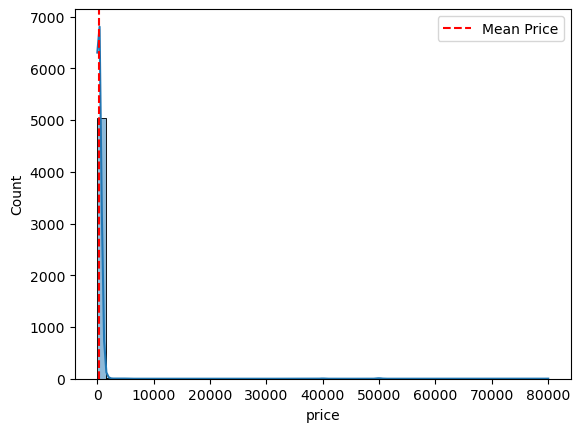

In [7]:
sns.histplot(train_df["price"], bins=50, kde=True)
plt.axvline(train_df["price"].mean(), color='red', linestyle='--', label='Mean Price')
plt.legend()

In [8]:
train_df["price"].describe()

count     5056.000000
mean       371.034612
std       2286.192999
min          8.000000
25%        162.000000
50%        224.000000
75%        315.000000
max      80018.000000
Name: price, dtype: float64

As one can see there are some outliers in the prices.

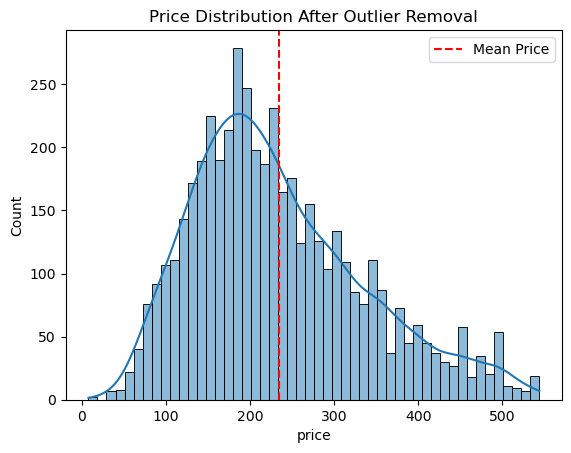

In [9]:
# Remove outliers using the IQR method
Q1 = train_df["price"].quantile(0.25)
Q3 = train_df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_df = train_df[(train_df["price"] >= lower_bound) & (train_df["price"] <= upper_bound)]

# plot the resulting price distribution after outlier removal
sns.histplot(train_df["price"], bins=50, kde=True)
plt.title("Price Distribution After Outlier Removal")
plt.axvline(train_df["price"].mean(), color='red', linestyle='--', label='Mean Price')
plt.legend()
plt.show()


In [10]:
train_df["price"].describe()

count    4776.000000
mean      234.057370
std       102.876986
min         8.000000
25%       158.750000
50%       216.000000
75%       296.000000
max       544.000000
Name: price, dtype: float64

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4776 entries, 0 to 5055
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   4776 non-null   object 
 1   description            4614 non-null   object 
 2   neighborhood_overview  2338 non-null   object 
 3   room_type              4776 non-null   object 
 4   amenities              4776 non-null   object 
 5   price                  4776 non-null   float64
 6   accommodates           4776 non-null   int64  
 7   bedrooms               4775 non-null   float64
 8   beds                   4768 non-null   float64
 9   bathrooms              4776 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 410.4+ KB


## Categorical features

In [12]:
# look at the room_type feature
train_df["room_type"].value_counts()

room_type
Entire home/apt    3648
Private room       1088
Shared room          21
Hotel room           19
Name: count, dtype: int64

Seems like the room_type can be simply one hot encoded

In [13]:
train_df = pd.get_dummies(train_df, columns=["room_type"], drop_first=False)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4776 entries, 0 to 5055
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       4776 non-null   object 
 1   description                4614 non-null   object 
 2   neighborhood_overview      2338 non-null   object 
 3   amenities                  4776 non-null   object 
 4   price                      4776 non-null   float64
 5   accommodates               4776 non-null   int64  
 6   bedrooms                   4775 non-null   float64
 7   beds                       4768 non-null   float64
 8   bathrooms                  4776 non-null   float64
 9   room_type_Entire home/apt  4776 non-null   bool   
 10  room_type_Hotel room       4776 non-null   bool   
 11  room_type_Private room     4776 non-null   bool   
 12  room_type_Shared room      4776 non-null   bool   
dtypes: bool(4), float64(4), int64(1), object(4)
memory us

## json data -- amenities

In [14]:
# look at what the amenities column looks like
train_df["amenities"].value_counts()

amenities
["Wifi", "Stove", "Luggage dropoff allowed", "Hair dryer", "Cooking basics", "Kitchen", "Oven", "Fire extinguisher", "First aid kit", "Elevator", "Hot water", "Bed linens", "Microwave", "Smoke alarm", "Refrigerator"]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    10
["Wifi", "Washer", "TV", "Kitchen", "Smoke alarm"]                                                                                             

In [15]:
from utils.data_processing import process_amenities
train_df = process_amenities(train_df)

In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4776 entries, 0 to 5055
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       4776 non-null   object 
 1   description                4614 non-null   object 
 2   neighborhood_overview      2338 non-null   object 
 3   price                      4776 non-null   float64
 4   accommodates               4776 non-null   int64  
 5   bedrooms                   4775 non-null   float64
 6   beds                       4768 non-null   float64
 7   bathrooms                  4776 non-null   float64
 8   room_type_Entire home/apt  4776 non-null   bool   
 9   room_type_Hotel room       4776 non-null   bool   
 10  room_type_Private room     4776 non-null   bool   
 11  room_type_Shared room      4776 non-null   bool   
 12  AC                         4776 non-null   bool   
 13  Soap                       4776 non-null   bool   
 1

# Process the text description data
TODO:
- merge all the text data into one column # Done
- process the text data (remove stop words, lemmatize, etc.)

## Merging the parts of descrioption

I want to treat name, description and neighborhood_overview as one big description as they contain different information about the house.
Since neighborhood_overview and description is not always present, we will fill the missing values with an empty string.

In [17]:
train_df["neighborhood_overview"] = train_df["neighborhood_overview"].fillna("")
train_df["description"] = train_df["description"].fillna("")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4776 entries, 0 to 5055
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       4776 non-null   object 
 1   description                4776 non-null   object 
 2   neighborhood_overview      4776 non-null   object 
 3   price                      4776 non-null   float64
 4   accommodates               4776 non-null   int64  
 5   bedrooms                   4775 non-null   float64
 6   beds                       4768 non-null   float64
 7   bathrooms                  4776 non-null   float64
 8   room_type_Entire home/apt  4776 non-null   bool   
 9   room_type_Hotel room       4776 non-null   bool   
 10  room_type_Private room     4776 non-null   bool   
 11  room_type_Shared room      4776 non-null   bool   
 12  AC                         4776 non-null   bool   
 13  Soap                       4776 non-null   bool   
 1

Combine the three columns into one column called "description", and remove the original columns.

In [18]:
train_df["description"] = train_df["name"] + " " + train_df["description"] + " " + train_df["neighborhood_overview"]
train_df.drop(columns=["name", "neighborhood_overview"], inplace=True)

In [19]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4776 entries, 0 to 5055
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   description                4776 non-null   object 
 1   price                      4776 non-null   float64
 2   accommodates               4776 non-null   int64  
 3   bedrooms                   4775 non-null   float64
 4   beds                       4768 non-null   float64
 5   bathrooms                  4776 non-null   float64
 6   room_type_Entire home/apt  4776 non-null   bool   
 7   room_type_Hotel room       4776 non-null   bool   
 8   room_type_Private room     4776 non-null   bool   
 9   room_type_Shared room      4776 non-null   bool   
 10  AC                         4776 non-null   bool   
 11  Soap                       4776 non-null   bool   
 12  Wardrobe                   4776 non-null   bool   
 13  HairConditioner            4776 non-null   bool   
 1

## Preporcess the description data for upcomming tokenization and Word2Vec 
[General Recomndations for text prepocessing](https://medium.com/product-ai/text-preprocessing-in-python-steps-tools-and-examples-bf025f872908)

In [20]:
from text_prepocessing import preprocessing
train_df = preprocessing(train_df)


d:\uni-Goettingen\SommerSemester 2025\Machine_Learning_Inf\Homeworks\MachineLearningExercises\Project\Description_model\text_prepocessing.py:29: SyntaxWarning: invalid escape sequence '\('
  df["description"]=df["description"].str.replace("\(\d\d\d\d\d\d\d\d\)", "")
d:\uni-Goettingen\SommerSemester 2025\Machine_Learning_Inf\Homeworks\MachineLearningExercises\Project\Description_model\text_prepocessing.py:62: SyntaxWarning: invalid escape sequence '\$'
  df["description"]=df["description"].str.replace('\$', " CAD ")
d:\uni-Goettingen\SommerSemester 2025\Machine_Learning_Inf\Homeworks\MachineLearningExercises\Project\Description_model\text_prepocessing.py:83: SyntaxWarning: invalid escape sequence '\d'
  re_results = re.findall('(\d+(st|nd|rd|th))', text)
d:\uni-Goettingen\SommerSemester 2025\Machine_Learning_Inf\Homeworks\MachineLearningExercises\Project\Description_model\text_prepocessing.py:141: SyntaxWarning: invalid escape sequence '\d'
  df["description"]=df["description"].str.repl

In [21]:
train_df["description"][0]

['luxurious',
 'family',
 'home',
 'amsterdam',
 'luxurious',
 'family',
 'home',
 '3',
 'bedroom',
 'near',
 'amsterdam',
 'city',
 'center',
 'perfect',
 'couple',
 'family',
 '2',
 '3',
 'child',
 'free',
 'indoor',
 'parking',
 'spacious',
 'roof',
 'terrace',
 'easy',
 'public',
 'transport',
 'tram',
 'metro',
 'bus',
 '20',
 'minute',
 'schiphol',
 'airport',
 'train',
 'metro',
 'subway',
 'perfect',
 'spot',
 'people',
 'enjoy',
 'sport',
 'especially',
 'jogging',
 'soccer',
 'tennis',
 'squash',
 'badminton',
 'able',
 'within',
 '200',
 'radius',
 'house',
 'area',
 'ha',
 'lot',
 'offer',
 'shop',
 'good',
 'food',
 'cultural',
 'event',
 'green',
 'park']